# ***Customer Churn Prediction Project***

## ***Import Necessary Libraries***

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

In [7]:
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## ***Load the Dataset***

In [10]:
df=pd.read_csv("C:/Users/priya/OneDrive/Desktop/Customer_Churn_Project/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [11]:
df.shape

(7043, 21)

In [12]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [14]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## ***Remove Duplicates***

In [21]:
df.drop_duplicates(inplace=True)

In [22]:
df.duplicated().sum()

np.int64(0)

## ***Finding Null Values***

In [23]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## ***Data Cleaning***

In [24]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [25]:
print("Missing values created:", df["TotalCharges"].isnull().sum())

Missing values created: 11


In [26]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [27]:
df = df.drop(columns=["customerID"]) #REMOVE UNNECESSARY COLUMNS

## ***Encoding the Target Columns***

In [28]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [29]:
df["Churn"].value_counts(normalize=True) * 100

Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64

## ***Exploratory Data Analysis***

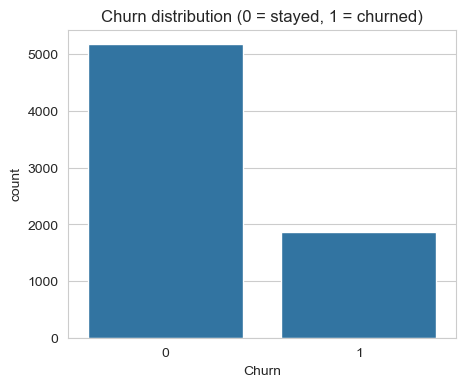

In [30]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="Churn")
plt.title("Churn distribution (0 = stayed, 1 = churned)")
plt.show()


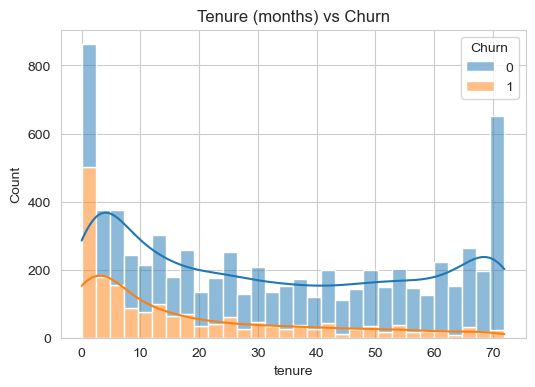

In [31]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True, multiple="stack")
plt.title("Tenure (months) vs Churn")
plt.show()

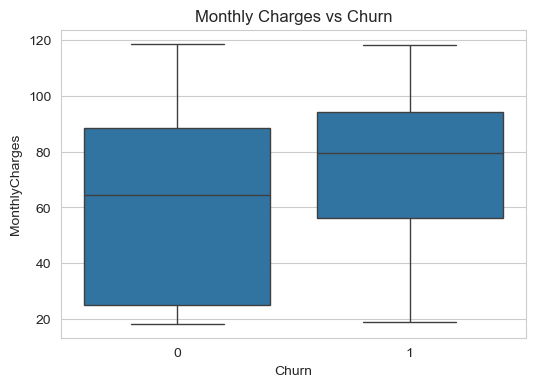

In [32]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.show()


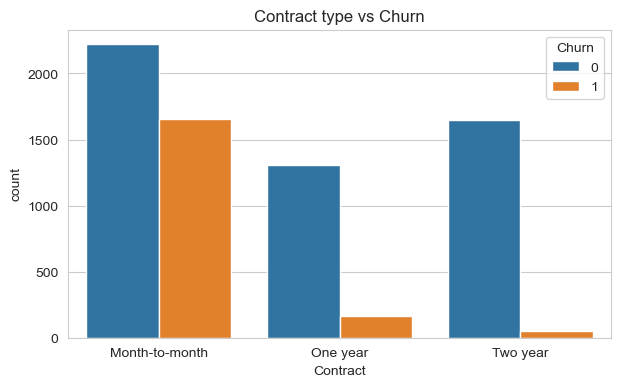

In [33]:
plt.figure(figsize=(7,4))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Contract type vs Churn")
plt.show()


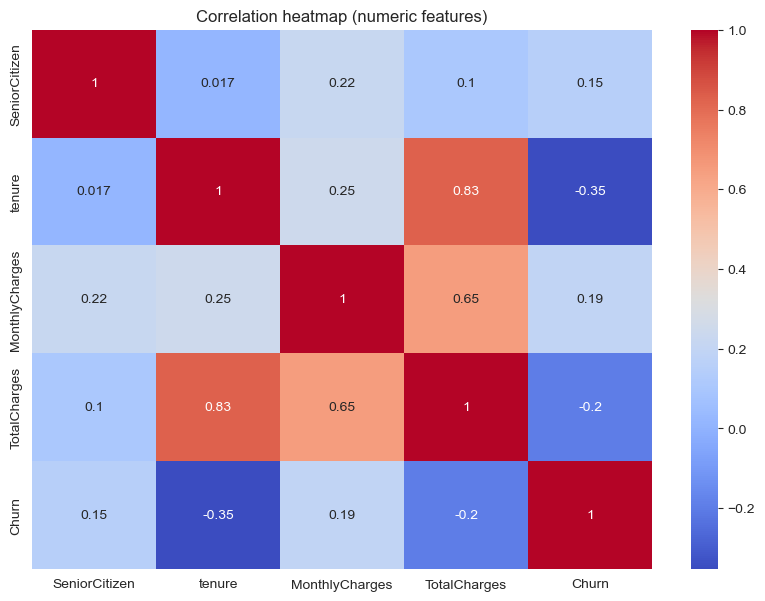

In [34]:
plt.figure(figsize=(10,7))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation heatmap (numeric features)")
plt.show()

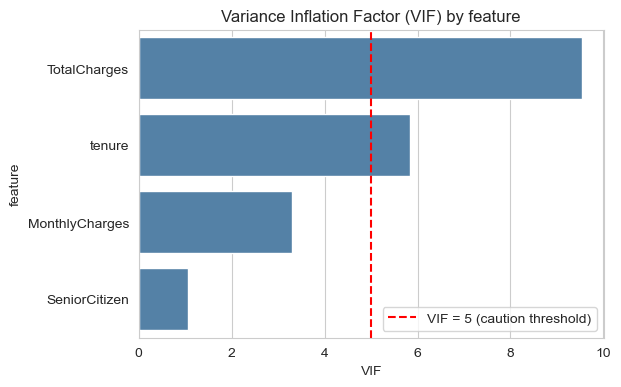

In [36]:
plt.figure(figsize=(6,4))
sns.barplot(data=vif_result.sort_values("VIF", ascending=False), x="VIF", y="feature", color="steelblue")
plt.axvline(5, color="red", linestyle="--", label="VIF = 5 (caution threshold)")
plt.title("Variance Inflation Factor (VIF) by feature")
plt.legend()
plt.show()


## ***Prepare Features for Machine Learning***

#### ***Split Features And Target***

In [37]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (7043, 19)
Target shape: (7043,)


#### ***Finding Numerical And Categorical Columns***

In [38]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


#### ***Train-Test Split***

In [39]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (5634, 19)
Test size: (1409, 19)


#### ***Build a PreProcessing + Model Pipeline***

In [41]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),])

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        class_weight="balanced")),])

#### ***Train the Model***

In [42]:
model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## ***Evaluate The Model***

In [44]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))
print("ROC-AUC score:", round(roc_auc_score(y_test, y_proba), 4))


              precision    recall  f1-score   support

    No Churn       0.89      0.79      0.84      1035
       Churn       0.55      0.72      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409

ROC-AUC score: 0.8391


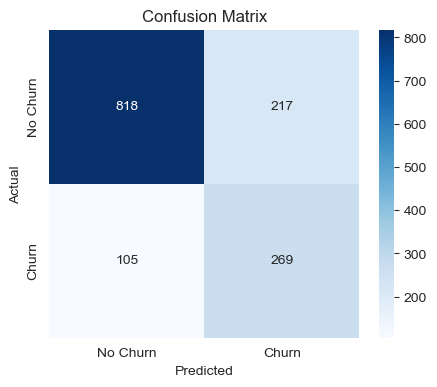

In [45]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

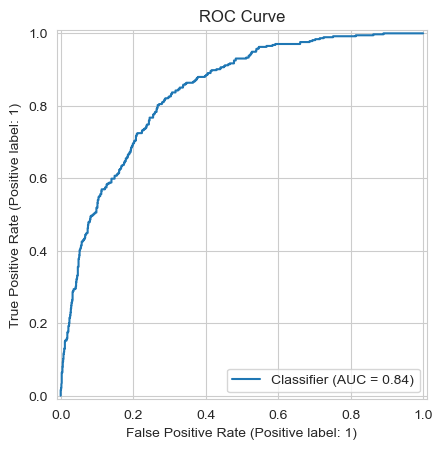

In [46]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("ROC Curve")
plt.show()

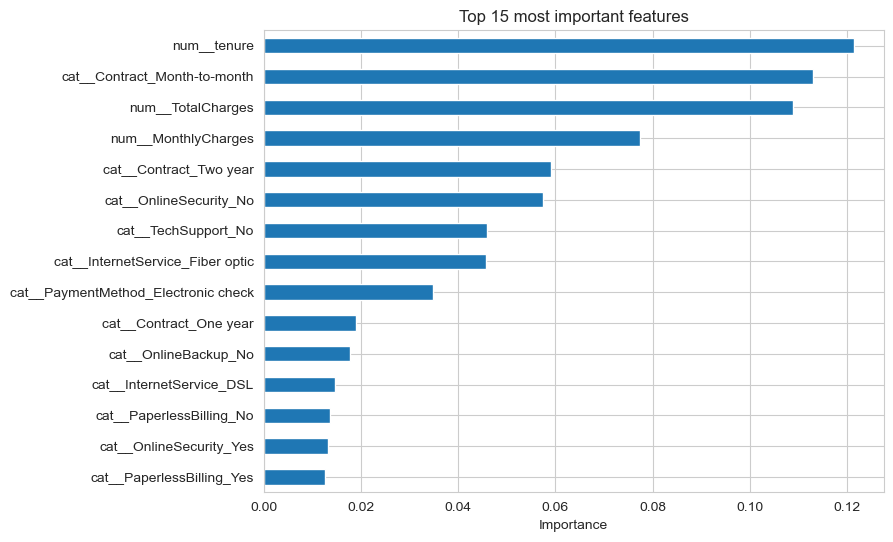

In [47]:
importances = model.named_steps["classifier"].feature_importances_
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(8,6))
feat_imp.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 most important features")
plt.xlabel("Importance")
plt.show()

## ***Predicting For New Customer Data***

In [48]:
new_customer = {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 2,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 95.0,
    "TotalCharges": 190.0,
}

new_df = pd.DataFrame([new_customer])

prediction = model.predict(new_df)[0]
probability = model.predict_proba(new_df)[0, 1]

print("Prediction:", "Will churn" if prediction == 1 else "Will stay")
print(f"Churn probability: {probability:.1%}")


Prediction: Will churn
Churn probability: 87.5%


## ***Predicting For Multiple New Customers***

In [49]:
new_customers_batch = pd.DataFrame([
    {
        "gender": "Male", "SeniorCitizen": 1, "Partner": "No", "Dependents": "No",
        "tenure": 1, "PhoneService": "Yes", "MultipleLines": "No",
        "InternetService": "Fiber optic", "OnlineSecurity": "No", "OnlineBackup": "No",
        "DeviceProtection": "No", "TechSupport": "No", "StreamingTV": "No",
        "StreamingMovies": "No", "Contract": "Month-to-month", "PaperlessBilling": "Yes",
        "PaymentMethod": "Electronic check", "MonthlyCharges": 80.0, "TotalCharges": 80.0,
    },
    {
        "gender": "Female", "SeniorCitizen": 0, "Partner": "Yes", "Dependents": "Yes",
        "tenure": 60, "PhoneService": "Yes", "MultipleLines": "Yes",
        "InternetService": "DSL", "OnlineSecurity": "Yes", "OnlineBackup": "Yes",
        "DeviceProtection": "Yes", "TechSupport": "Yes", "StreamingTV": "No",
        "StreamingMovies": "No", "Contract": "Two year", "PaperlessBilling": "No",
        "PaymentMethod": "Bank transfer (automatic)", "MonthlyCharges": 55.0, "TotalCharges": 3300.0,
    },
])

results = new_customers_batch.copy()
results["churn_prediction"] = model.predict(new_customers_batch)
results["churn_probability"] = model.predict_proba(new_customers_batch)[:, 1]

results[["tenure", "Contract", "MonthlyCharges", "churn_prediction", "churn_probability"]]


,tenure,Contract,MonthlyCharges,churn_prediction,churn_probability
0,1,Month-to-month,80.0,1,0.911096
1,60,Two year,55.0,0,0.028363


## ***Saved The Training Model***

In [50]:
import joblib

joblib.dump(model, "churn_model.pkl")
print("Model saved as churn_model.pkl")

Model saved as churn_model.pkl


In [51]:
loaded_model = joblib.load("churn_model.pkl")

check_prediction = loaded_model.predict(new_df)[0]
print("Loaded model prediction matches original:", check_prediction == prediction)

Loaded model prediction matches original: True
